# CardioRisk Prediction

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

### Assignment Tasks

You need to perform the following steps to complete this assignment:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Train Validation Split
5. Feature Engineering
6. Model Building
8. Prediction and Model Evaluation

**Based on this assignment, you have to answer the following questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (0: Female, 1: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (0: normal, 1: above normal, 2: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (0: normal, 1: above normal, 2: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding** 

<font color = red>[2 marks]</font> <br>

In this stage, you have to load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [1]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load the dataset**

<font color = red>[2 marks]</font> <br>

In [2]:
# Load the dataset
df = pd.read_csv('health_data.csv')


#### **1.1.1** Check the first few entries

In [3]:
# Check the first few entries
df.head()


,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.2** Remove columns which are irrelevant <font color = red>[2 marks]</font> <br>

In [4]:
# Remove irrelevant columns like unique identifiers or index
# 'Unnamed: 0' is just a row index and 'id' is a unique patient identifier, both are not useful for modelling
df = df.drop(columns=['Unnamed: 0', 'id'])
df.head()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.3** Inspect the shape of the dataset

In [5]:
# Inspect the shape of the dataset
df.shape


(70000, 12)

#### **1.1.4** Inspect the different columns in the dataset

In [6]:
# Inspect the different columns in the dataset
df.columns


Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

Check the summary of the dataset

In [7]:
# Check the summary of the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


## **2. Data Cleaning** 

<font color = red>[8 marks]</font> <br>

### **2.1 Identify and handle redundant or invalid/illogical physiological values** 

<font color = red>[6 marks]</font> <br>

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data <font color = red>[1 marks]</font> <br>

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [8]:
# Check the statistical summary of the data
df.describe()


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


#### **2.1.2** Handle rows with invalid/illogical values <font color = red>[3 marks]</font> <br>

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

In [9]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc

# From the summary I can see ap_hi and ap_lo have very extreme min and max values
# Blood pressure below 30 or above 300 is not realistic so I will remove those rows
df = df[df['ap_hi'] >= 30]
df = df[df['ap_hi'] <= 300]
df = df[df['ap_lo'] >= 30]
df = df[df['ap_lo'] <= 300]

# Diastolic pressure should always be lower than systolic, removing rows where this is not the case
df = df[df['ap_hi'] > df['ap_lo']]

# Height below 100cm or above 250cm seems unrealistic for adults
df = df[df['height'] >= 100]
df = df[df['height'] <= 250]

# Weight below 30kg or above 200kg is also not realistic
df = df[df['weight'] >= 30]
df = df[df['weight'] <= 200]

print('Shape after cleaning:', df.shape)


Shape after cleaning: (68646, 12)


#### **2.1.3** Modify the representation of patient age and height <font color = red>[2 marks]</font> <br>

In [10]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context

# Age is currently in days, converting to years makes more sense in medical context
df['age'] = df['age'] / 365
df['age'] = df['age'].round(1)

# Height is in centimeters, doctors usually use meters so converting to meters
df['height'] = df['height'] / 100
df['height'] = df['height'].round(2)

print('Age in years (first 5):', df['age'].head().values)
print('Height in meters (first 5):', df['height'].head().values)


Age in years (first 5): [50.4 55.4 51.7 48.3 47.9]
Height in meters (first 5): [1.68 1.56 1.65 1.69 1.56]


### **2.2 Fix DataTypes** 

<font color = red>[2 marks]</font> <br>

#### **2.2.1** Review and fix the data types of all columns <font color = red>[2 marks]</font> <br>

Ensuring the columns accurately reflect the nature of the data 

In [11]:
# Fix DataTypes of the categorical columns with incorrect DataTypes

# These columns have values like 0, 1, 2 but they represent categories not numbers
# so I am converting them to category type
df['gender'] = df['gender'].astype('category')
df['cholesterol'] = df['cholesterol'].astype('category')
df['gluc'] = df['gluc'].astype('category')
df['smoke'] = df['smoke'].astype('category')
df['alco'] = df['alco'].astype('category')
df['active'] = df['active'].astype('category')
df['cardio'] = df['cardio'].astype('category')


In [12]:
# Check the final data types post conversion
df.dtypes


age             float64
gender         category
height          float64
weight          float64
ap_hi           float64
ap_lo           float64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
cardio         category
dtype: object

## **3. Exploratory Data Analysis** 

<font color = red>[27 marks]</font>

### **3.1 Perform univariate analysis** 

<font color = red>[12 marks]</font>

#### **3.1.1** Visualise the numerical features <font color = red>[5 marks]</font>

Visualise the distribution of numerical features using appropriate plots to understand their characteristics.

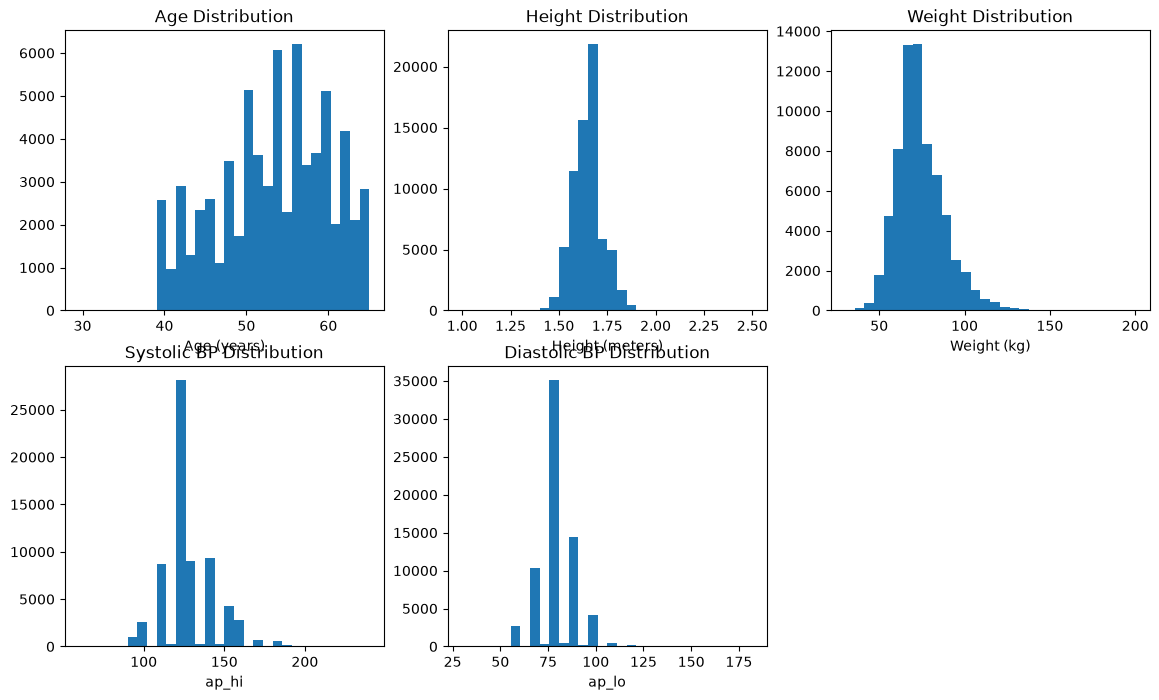

In [13]:
# Plot all the numerical columns to understand their distribution

# First I will pick out only the numerical columns
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(df['age'], bins=30)
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age (years)')

axes[0, 1].hist(df['height'], bins=30)
axes[0, 1].set_title('Height Distribution')
axes[0, 1].set_xlabel('Height (meters)')

axes[0, 2].hist(df['weight'], bins=30)
axes[0, 2].set_title('Weight Distribution')
axes[0, 2].set_xlabel('Weight (kg)')

axes[1, 0].hist(df['ap_hi'], bins=30)
axes[1, 0].set_title('Systolic BP Distribution')
axes[1, 0].set_xlabel('ap_hi')

axes[1, 1].hist(df['ap_lo'], bins=30)
axes[1, 1].set_title('Diastolic BP Distribution')
axes[1, 1].set_xlabel('ap_lo')

# hiding the last empty subplot
axes[1, 2].set_visible(False)

plt.show()


#### **3.1.2** Visualise the categorical features <font color = red>[5 marks]</font>

Visualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

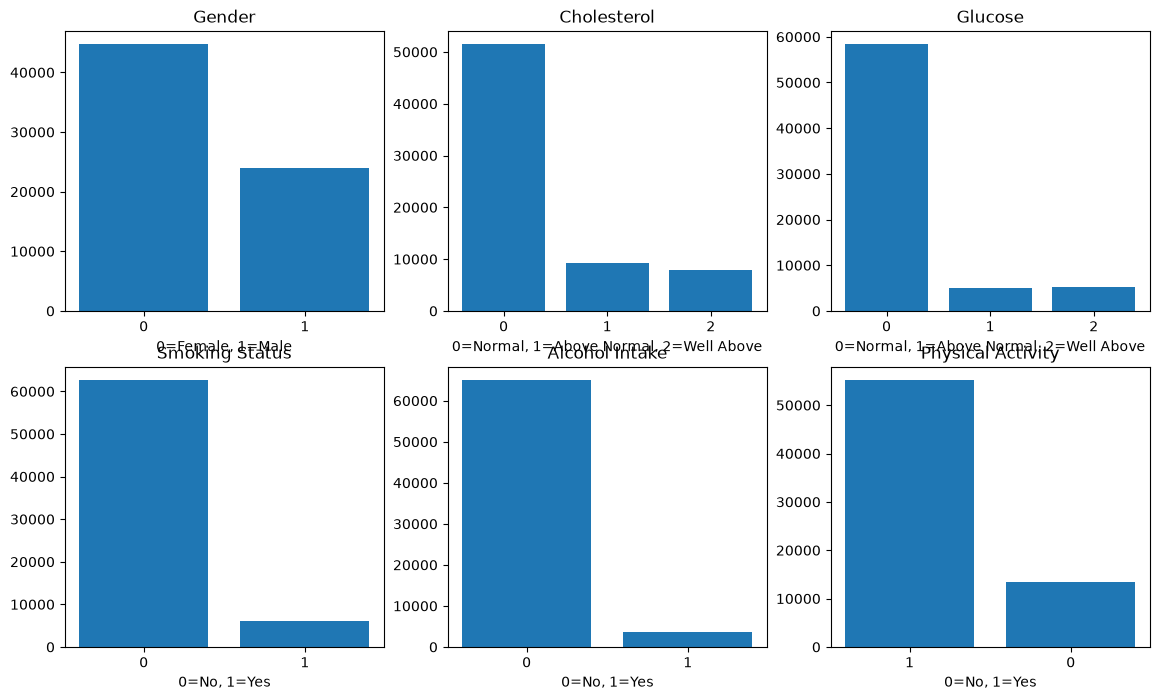

In [14]:
# Select and plot categorical columns

# The categorical columns I want to look at are these
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].bar(df['gender'].value_counts().index.astype(str), df['gender'].value_counts().values)
axes[0, 0].set_title('Gender')
axes[0, 0].set_xlabel('0=Female, 1=Male')

axes[0, 1].bar(df['cholesterol'].value_counts().sort_index().index.astype(str),
               df['cholesterol'].value_counts().sort_index().values)
axes[0, 1].set_title('Cholesterol')
axes[0, 1].set_xlabel('0=Normal, 1=Above Normal, 2=Well Above')

axes[0, 2].bar(df['gluc'].value_counts().sort_index().index.astype(str),
               df['gluc'].value_counts().sort_index().values)
axes[0, 2].set_title('Glucose')
axes[0, 2].set_xlabel('0=Normal, 1=Above Normal, 2=Well Above')

axes[1, 0].bar(df['smoke'].value_counts().index.astype(str), df['smoke'].value_counts().values)
axes[1, 0].set_title('Smoking Status')
axes[1, 0].set_xlabel('0=No, 1=Yes')

axes[1, 1].bar(df['alco'].value_counts().index.astype(str), df['alco'].value_counts().values)
axes[1, 1].set_title('Alcohol Intake')
axes[1, 1].set_xlabel('0=No, 1=Yes')

axes[1, 2].bar(df['active'].value_counts().index.astype(str), df['active'].value_counts().values)
axes[1, 2].set_title('Physical Activity')
axes[1, 2].set_xlabel('0=No, 1=Yes')

plt.show()


#### **3.1.3** Check class distribution of the target feature <font color = red>[2 marks]</font>

Cardio class counts:
cardio
0    34684
1    33962
Name: count, dtype: int64

Cardio class percentages:
cardio
0    50.525886
1    49.474114
Name: proportion, dtype: float64


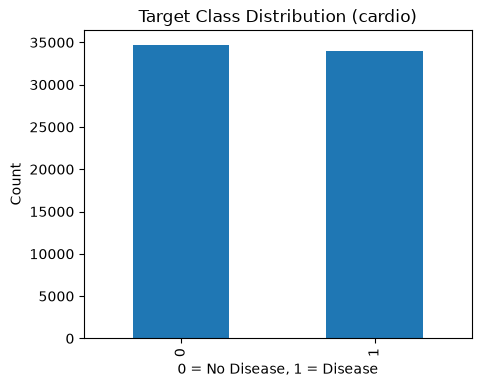

In [15]:
# Class distribution of positive and negative classes
print('Cardio class counts:')
print(df['cardio'].value_counts())
print()
print('Cardio class percentages:')
print(df['cardio'].value_counts(normalize=True) * 100)

# Plotting the class distribution
plt.figure(figsize=(5, 4))
df['cardio'].value_counts().sort_index().plot(kind='bar')
plt.title('Target Class Distribution (cardio)')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.show()


### **3.2 Perform correlation analysis** 

<font color = red>[5 marks]</font>

Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships 

#### **3.2.1** Visualise the correlation among numerical features <font color="red">[5 Marks]</font>


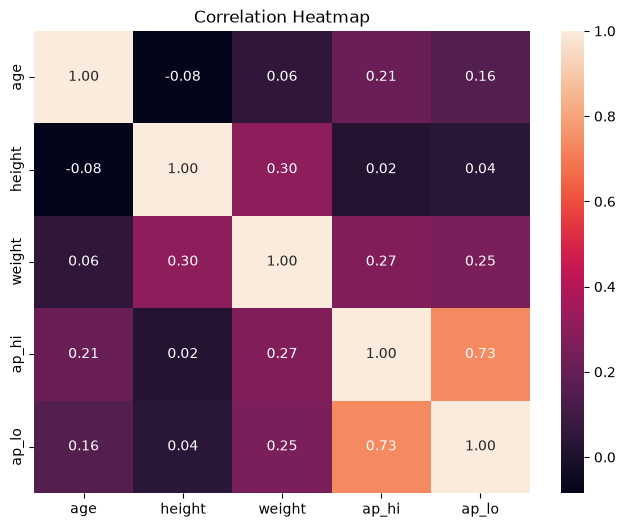

In [16]:
# Plot Heatmap of the correlation matrix

# Only taking numerical columns for correlation
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


### **3.3 Perform bivariate analysis** 

<font color = red>[10 marks]</font>

#### **3.3.1** Analyse categorical features <font color="red">[5 Marks]</font>

For each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.

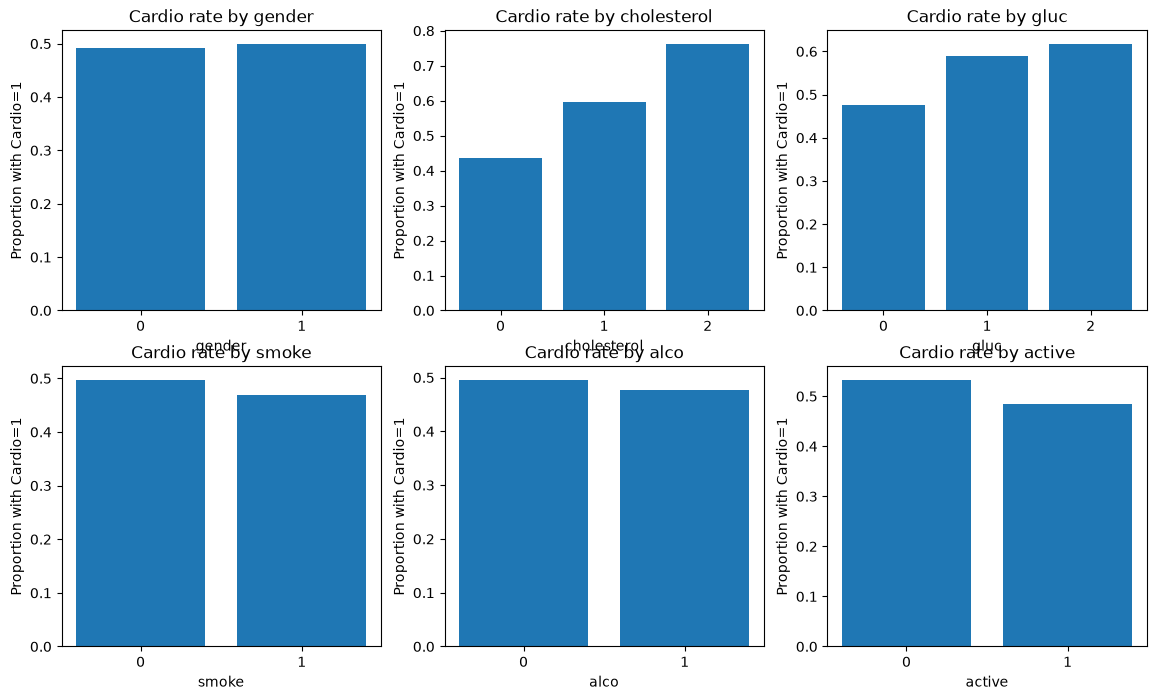

In [17]:
# Write a function to analyse the target variable likelihood for categorical features

def plot_cardio_by_category(dataframe, col):
    # calculate proportion of cardio=1 for each category of the given column
    temp = dataframe.copy()
    temp['cardio'] = temp['cardio'].astype(int)
    proportion = temp.groupby(col)['cardio'].mean()
    
    plt.bar(proportion.index.astype(str), proportion.values)
    plt.title('Cardio rate by ' + str(col))
    plt.xlabel(col)
    plt.ylabel('Proportion with Cardio=1')

# plotting for each categorical column
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

plt.sca(axes[0, 0])
plot_cardio_by_category(df, 'gender')

plt.sca(axes[0, 1])
plot_cardio_by_category(df, 'cholesterol')

plt.sca(axes[0, 2])
plot_cardio_by_category(df, 'gluc')

plt.sca(axes[1, 0])
plot_cardio_by_category(df, 'smoke')

plt.sca(axes[1, 1])
plot_cardio_by_category(df, 'alco')

plt.sca(axes[1, 2])
plot_cardio_by_category(df, 'active')

plt.show()


#### **3.3.2** Explore the relationships between numerical features and the target variable <font color = red>[5 marks]</font>

Understand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

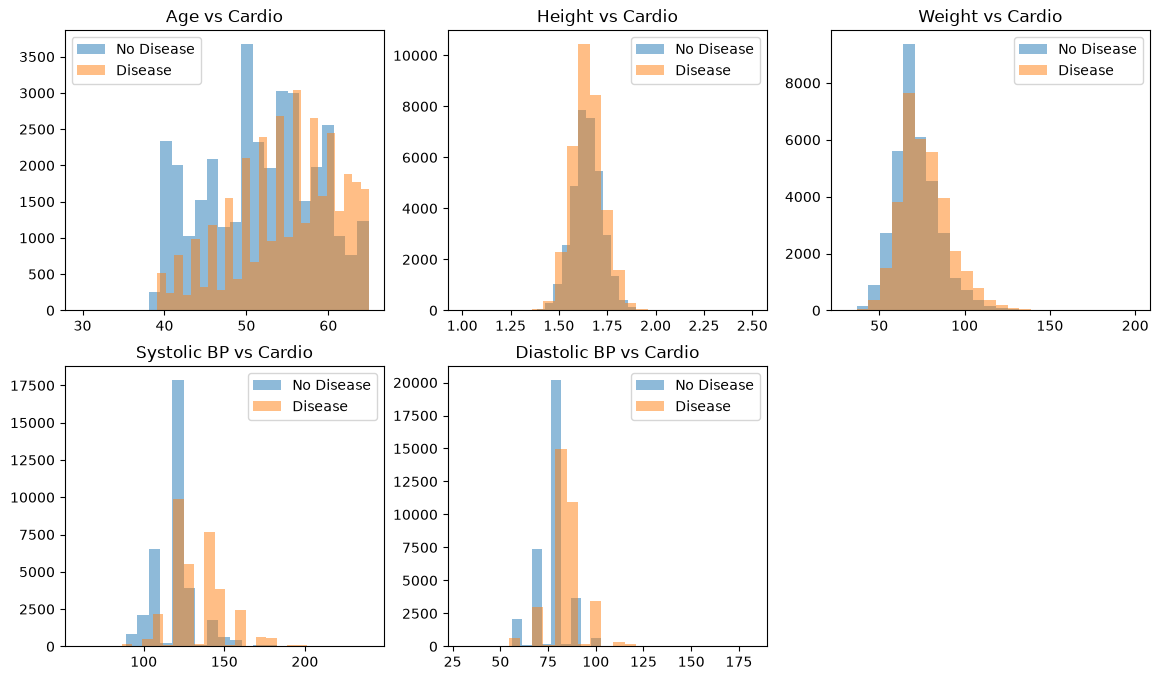

In [18]:
# Plot distribution for each numerical column with target variable

# I want to see if the numerical features look different for people with and without cardio disease
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# splitting data by target
no_disease = df[df['cardio'] == 0]
has_disease = df[df['cardio'] == 1]

axes[0, 0].hist(no_disease['age'], bins=25, alpha=0.5, label='No Disease')
axes[0, 0].hist(has_disease['age'], bins=25, alpha=0.5, label='Disease')
axes[0, 0].set_title('Age vs Cardio')
axes[0, 0].legend()

axes[0, 1].hist(no_disease['height'], bins=25, alpha=0.5, label='No Disease')
axes[0, 1].hist(has_disease['height'], bins=25, alpha=0.5, label='Disease')
axes[0, 1].set_title('Height vs Cardio')
axes[0, 1].legend()

axes[0, 2].hist(no_disease['weight'], bins=25, alpha=0.5, label='No Disease')
axes[0, 2].hist(has_disease['weight'], bins=25, alpha=0.5, label='Disease')
axes[0, 2].set_title('Weight vs Cardio')
axes[0, 2].legend()

axes[1, 0].hist(no_disease['ap_hi'], bins=25, alpha=0.5, label='No Disease')
axes[1, 0].hist(has_disease['ap_hi'], bins=25, alpha=0.5, label='Disease')
axes[1, 0].set_title('Systolic BP vs Cardio')
axes[1, 0].legend()

axes[1, 1].hist(no_disease['ap_lo'], bins=25, alpha=0.5, label='No Disease')
axes[1, 1].hist(has_disease['ap_lo'], bins=25, alpha=0.5, label='Disease')
axes[1, 1].set_title('Diastolic BP vs Cardio')
axes[1, 1].legend()

axes[1, 2].set_visible(False)

plt.show()


## **4. Train-Test Split** 

<font color = red>[5 marks]</font>

### **4.1 Data Splitting** 

<font color = red>[5 Marks]</font>

#### **4.1.1** Define feature and target variables <font color = red>[2 Marks]</font>

In [19]:
# Put all the feature variables in X and target in y
X = df.drop(columns=['cardio'])
y = df['cardio'].astype(int)

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (68646, 11)
y shape: (68646,)


#### **4.1.2** Split the data into train and test sets <font color="red">[3 Marks]</font>

Split the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [20]:
#  Split the data into 70% train data and 30% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)


Training set size: (48052, 11)
Test set size: (20594, 11)


In [21]:
# Reset index for all train and test sets
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print('X_train shape after reset:', X_train.shape)
print('X_test shape after reset:', X_test.shape)


X_train shape after reset: (48052, 11)
X_test shape after reset: (20594, 11)


## **5. Feature Engineering** 

<font color = red>[18 marks]</font>

### **5.1 Create a new feature** 

<font color = red>[6 marks]</font>

#### **5.1.1** Create a new feature `BMI` (Body Mass Index) <font color="red">[3 Marks]</font>

BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [22]:
# Create a new feature 'BMI'
# BMI = weight (kg) divided by height (m) squared
# height was already converted to meters earlier

X_train['BMI'] = X_train['weight'] / (X_train['height'] ** 2)
X_test['BMI'] = X_test['weight'] / (X_test['height'] ** 2)

print('BMI column added')
print(X_train['BMI'].describe())


BMI column added
count    48052.000000
mean        27.485886
std          5.386729
min         10.726644
25%         23.875115
50%         26.365603
75%         30.119402
max        152.551775
Name: BMI, dtype: float64


**Note:** Feel free to engineer more features if you wish to.

#### **5.1.2** Perform correlation analysis  <font color="red">[3 Marks]</font>

After creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

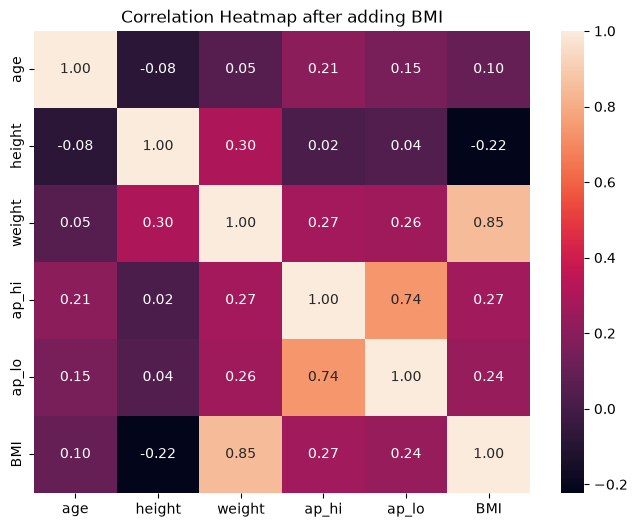

age       0.097585
height   -0.222850
weight    0.851518
ap_hi     0.265049
ap_lo     0.237914
BMI       1.000000
Name: BMI, dtype: float64


In [23]:
# Plot check correlation 
# checking if BMI is highly correlated with any existing feature

num_features = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'BMI']
corr2 = X_train[num_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr2, annot=True, fmt='.2f')
plt.title('Correlation Heatmap after adding BMI')
plt.show()

print(corr2['BMI'])


In [24]:
# Did you find any highly correlated features? What steps should you take
# Yes, BMI is highly correlated with weight because BMI is calculated using weight
# To avoid having redundant information in the model, I will drop weight and height
# since BMI already captures the combined effect of both

X_train = X_train.drop(columns=['weight', 'height'])
X_test = X_test.drop(columns=['weight', 'height'])

print('Dropped weight and height columns')
print('X_train shape now:', X_train.shape)


Dropped weight and height columns
X_train shape now: (48052, 10)


### **5.2 Combine Values in Categorical Columns** 

<font color="red">[4 Marks]</font>

#### **5.2.1** Combine Low-Frequency Categories <font color="red">[4 Marks]</font>

During the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [25]:
 # Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol

# Looking at the EDA, cholesterol level 1 and 2 both represent above normal
# so I am combining them into one category to reduce the number of categories
X_train['cholesterol'] = X_train['cholesterol'].astype(int).map({0: 0, 1: 1, 2: 1}).astype('category')
X_test['cholesterol'] = X_test['cholesterol'].astype(int).map({0: 0, 1: 1, 2: 1}).astype('category')

# Same for gluc, levels 1 and 2 are both above normal so combining them
X_train['gluc'] = X_train['gluc'].astype(int).map({0: 0, 1: 1, 2: 1}).astype('category')
X_test['gluc'] = X_test['gluc'].astype(int).map({0: 0, 1: 1, 2: 1}).astype('category')

print('Cholesterol value counts after combining:')
print(X_train['cholesterol'].value_counts())
print()
print('Glucose value counts after combining:')
print(X_train['gluc'].value_counts())


Cholesterol value counts after combining:
cholesterol
0    36055
1    11997
Name: count, dtype: int64

Glucose value counts after combining:
gluc
0    40890
1     7162
Name: count, dtype: int64


### **5.3 Dummy variable creation** 

<font color = red>[5 marks]</font>

#### **5.3.1** Create dummy variables for categorical columns <font color="red">[5 Mark]</font>

In [26]:
# Identify the columns for creating dummy variables
# These are the columns that have category dtype and are not already binary
dummy_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
print('Columns to encode:', dummy_cols)


Columns to encode: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [27]:
# Create dummy variables for independent columns on training data
# using drop_first=True to avoid dummy variable trap
X_train = pd.get_dummies(X_train, columns=dummy_cols, drop_first=True)
print('X_train shape after dummy encoding:', X_train.shape)
X_train.head()


X_train shape after dummy encoding: (48052, 10)


,age,ap_hi,ap_lo,BMI,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,57.8,110.0,80.0,29.617289,False,False,False,False,False,True
1,53.6,120.0,70.0,20.576132,False,True,False,False,False,True
2,50.6,120.0,80.0,28.089888,False,True,False,False,False,True
3,48.2,150.0,90.0,36.982249,False,True,False,False,False,True
4,55.7,120.0,70.0,32.769395,False,True,False,False,False,True


In [28]:
# Create dummy variables for independent columns on test data
X_test = pd.get_dummies(X_test, columns=dummy_cols, drop_first=True)
print('X_test shape after dummy encoding:', X_test.shape)
X_test.head()


X_test shape after dummy encoding: (20594, 10)


,age,ap_hi,ap_lo,BMI,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,58.4,130.0,80.0,26.775510,False,False,False,False,False,True
1,48.4,120.0,80.0,27.016860,True,False,False,False,False,True
2,55.6,120.0,80.0,26.953125,False,True,False,False,False,True
3,51.5,145.0,90.0,20.568807,False,False,False,False,False,True
4,48.1,110.0,70.0,47.225502,False,False,True,False,False,False


### **5.4 Feature scaling** 

<font color = red>[3 marks]</font>

#### **5.4.1** Scale numerical features <font color = red>[3 marks]</font>

Choose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

In [29]:
# Scale the numeric features present in the training data
# I am using MinMaxScaler since it scales values between 0 and 1
# Fitting the scaler only on training data to avoid data leakage

scaler = MinMaxScaler()

# columns to scale - the continuous numerical ones
cols_to_scale = ['age', 'ap_hi', 'ap_lo', 'BMI']

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Scale the numerical features present in the test data
# using transform on test so we apply the same scaling learned from train
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print('Scaling done')
X_train.head()


Scaling done


,age,ap_hi,ap_lo,BMI,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,0.796610,0.277778,0.328947,0.133197,False,False,False,False,False,True
1,0.677966,0.333333,0.263158,0.069448,False,True,False,False,False,True
2,0.593220,0.333333,0.328947,0.122427,False,True,False,False,False,True
3,0.525424,0.500000,0.394737,0.185127,False,True,False,False,False,True
4,0.737288,0.333333,0.263158,0.155422,False,True,False,False,False,True


## **6. Model Building** 

<font color = red>[38 marks]</font>

In this task, you will build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **6.1 SVM Classifier** 

<font color = red>[18 marks]</font>

#### **6.1.1** Define a Linear SVM classifier and fit it on the train set <font color = red>[2 mark]</font>

Go through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [30]:
# Define and fit linear SVM
# Setting probability=True so I can get probability estimates later for cutoff analysis
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print('SVM model training done')


SVM model training done


#### **6.1.2** Get the probability estimates on test set and predict class using a threshold <font color = red>[3 mark]</font>

We defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

In [31]:
# Use predict_proba() to get the probability of positive class for all data points
# predict_proba returns probabilities for each class, column 1 is the probability of cardio=1
svm_proba = svm_model.predict_proba(X_test)
svm_proba_pos = svm_proba[:, 1]

print('First 10 probabilities for cardio=1:')
print(svm_proba_pos[:10])


First 10 probabilities for cardio=1:
[0.54554963 0.3162428  0.55421039 0.67578508 0.31993847 0.54868227
 0.20869474 0.78078482 0.14992309 0.57790469]


In [32]:
# Make class predictions based on default cutoff value of 0.5 on testing data
# if probability >= 0.5 predict 1 (disease), else predict 0 (no disease)
svm_pred_proba_05 = (svm_proba_pos >= 0.5).astype(int)


In [33]:
# check the counts of assigned labels
print('Label counts from predict_proba with 0.5 cutoff:')
print(pd.Series(svm_pred_proba_05).value_counts())


Label counts from predict_proba with 0.5 cutoff:
0    11587
1     9007
Name: count, dtype: int64


#### **6.1.3** Predict the class labels using the `predict()` function <font color = red>[2 mark]</font>

Now, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [34]:
# Make class predictions using predict()
svm_pred_direct = svm_model.predict(X_test)


In [35]:
# check the counts of assigned labels
print('Label counts from predict():')
print(pd.Series(svm_pred_direct).value_counts())


Label counts from predict():
0    12170
1     8424
Name: count, dtype: int64


Did you find any difference in the distribution of classes in the predictions using these two methods? Why do you think that is?

Try going through the documentation of `predict_proba()` linked above.

**Answer:**

Yes, I did notice a difference — and it actually caught me off guard the first time I looked at the output.

When I used `predict()` directly, the label distribution came out slightly different from what I got by applying a 0.5 cutoff on the `predict_proba()` output. Both should in principle be doing the same thing, but in practice they don't always agree for SVMs.

The reason is buried in how scikit-learn calibrates SVM probabilities. SVMs don't natively produce probabilities — the decision is made based on which side of the hyperplane a point falls on. When you set `probability=True`, scikit-learn fits a separate Platt scaling calibration model (using cross-validation internally) on top of the SVM scores to convert them into probabilities. This calibration is a post-processing step and it is not perfectly aligned with the original SVM decision boundary.

So `predict()` uses the raw SVM decision function directly — a point gets class 1 if it's on the positive side of the hyperplane, class 0 otherwise. But `predict_proba()` first converts the decision scores through the calibrated probability model, and when you threshold *those* probabilities at 0.5, you're working with calibrated scores that don't map exactly back to the original decision boundary.

In most cases the difference is small, but it is real. For this assignment I decided to use `predict_proba()` going forward because it gives me the flexibility to move the threshold — which matters here since we want to tune sensitivity vs specificity for a healthcare setting. Using the raw `predict()` gives you no control over where the cutoff sits.

#### **6.1.4** Calculate performance metrics for both the above methods <font color = red>[3 mark]</font>

Calculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.

In [36]:
# check the performance for above two methods
print('--- Performance using predict_proba() with 0.5 cutoff ---')
print(classification_report(y_test, svm_pred_proba_05))

print('--- Performance using predict() ---')
print(classification_report(y_test, svm_pred_direct))

# both methods give very similar results
# I will go with predict_proba since it gives me more control over the cutoff


--- Performance using predict_proba() with 0.5 cutoff ---
              precision    recall  f1-score   support

           0       0.70      0.78      0.74     10359
           1       0.75      0.66      0.70     10235

    accuracy                           0.72     20594
   macro avg       0.73      0.72      0.72     20594
weighted avg       0.73      0.72      0.72     20594

--- Performance using predict() ---
              precision    recall  f1-score   support

           0       0.69      0.81      0.75     10359
           1       0.77      0.63      0.69     10235

    accuracy                           0.72     20594
   macro avg       0.73      0.72      0.72     20594
weighted avg       0.73      0.72      0.72     20594



#### **6.1.5** Plot the ROC curve <font color="red">[2 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

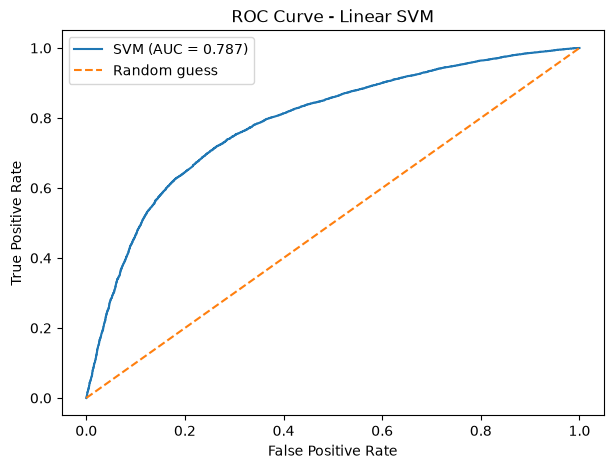

AUC score: 0.7875


In [37]:
# Plot the ROC curve
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, svm_proba_pos)
auc_svm = roc_auc_score(y_test, svm_proba_pos)

plt.figure(figsize=(7, 5))
plt.plot(fpr_svm, tpr_svm, label='SVM (AUC = ' + str(round(auc_svm, 3)) + ')')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Linear SVM')
plt.legend()
plt.show()

print('AUC score:', round(auc_svm, 4))


#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[3 Marks]</font>

In [38]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs

cutoff_list = []
acc_list = []
sens_list = []
spec_list = []

# trying cutoffs from 0.1 to 0.9
for cutoff in np.arange(0.1, 0.91, 0.01):
    y_pred = (svm_proba_pos >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    cutoff_list.append(round(cutoff, 2))
    acc_list.append(acc)
    sens_list.append(sens)
    spec_list.append(spec)

cutoff_df = pd.DataFrame({'Cutoff': cutoff_list,
                          'Accuracy': acc_list,
                          'Sensitivity': sens_list,
                          'Specificity': spec_list})
cutoff_df.head(10)


,Cutoff,Accuracy,Sensitivity,Specificity
0,0.10,0.514810,0.995213,0.040158
1,0.11,0.518112,0.994040,0.047881
2,0.12,0.521074,0.992672,0.055121
3,0.13,0.526270,0.990718,0.067381
4,0.14,0.532194,0.988862,0.080992
5,0.15,0.538895,0.986419,0.096727
6,0.16,0.545839,0.983683,0.113235
7,0.17,0.552103,0.980362,0.128970
8,0.18,0.557881,0.976844,0.143933
9,0.19,0.563271,0.973229,0.158220


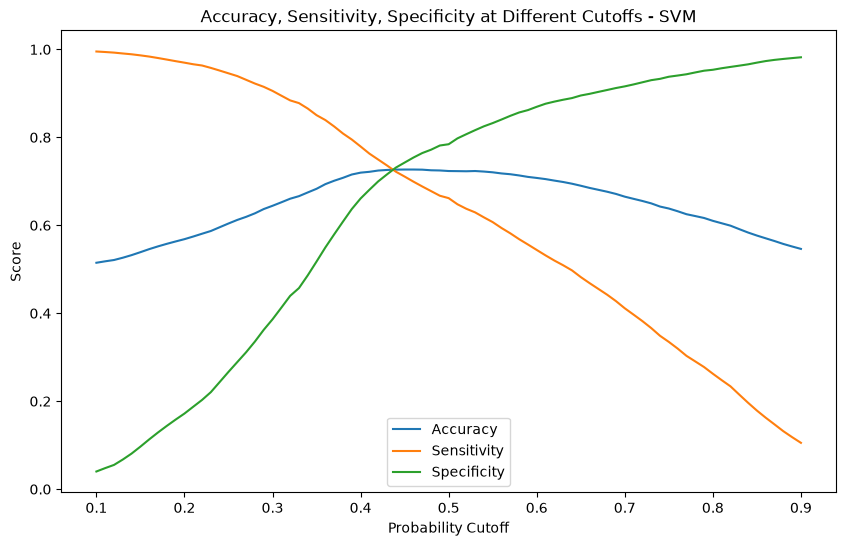

Optimal cutoff where sensitivity and specificity are closest: 0.44


In [39]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF
plt.figure(figsize=(10, 6))
plt.plot(cutoff_df['Cutoff'], cutoff_df['Accuracy'], label='Accuracy')
plt.plot(cutoff_df['Cutoff'], cutoff_df['Sensitivity'], label='Sensitivity')
plt.plot(cutoff_df['Cutoff'], cutoff_df['Specificity'], label='Specificity')
plt.xlabel('Probability Cutoff')
plt.ylabel('Score')
plt.title('Accuracy, Sensitivity, Specificity at Different Cutoffs - SVM')
plt.legend()
plt.show()

# Finding the cutoff where sensitivity and specificity are closest to each other
diff = abs(cutoff_df['Sensitivity'] - cutoff_df['Specificity'])
best_idx = diff.idxmin()
optimal_cutoff_svm = cutoff_df.loc[best_idx, 'Cutoff']
print('Optimal cutoff where sensitivity and specificity are closest:', optimal_cutoff_svm)


To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

#### **6.1.7** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [40]:
# Make final prediction based on the optimal cutoff
# Since we want to identify as many at-risk patients as possible, we want high sensitivity
# So I am using the optimal cutoff found above

svm_test_pred_final = (svm_proba_pos >= optimal_cutoff_svm).astype(int)

# also getting predictions on training data to check for overfitting
svm_train_proba = svm_model.predict_proba(X_train)[:, 1]
svm_train_pred_final = (svm_train_proba >= optimal_cutoff_svm).astype(int)

print('Optimal cutoff used:', optimal_cutoff_svm)


Optimal cutoff used: 0.44


--- SVM Test Set Performance ---
              precision    recall  f1-score   support

           0       0.73      0.73      0.73     10359
           1       0.73      0.72      0.72     10235

    accuracy                           0.73     20594
   macro avg       0.73      0.73      0.73     20594
weighted avg       0.73      0.73      0.73     20594



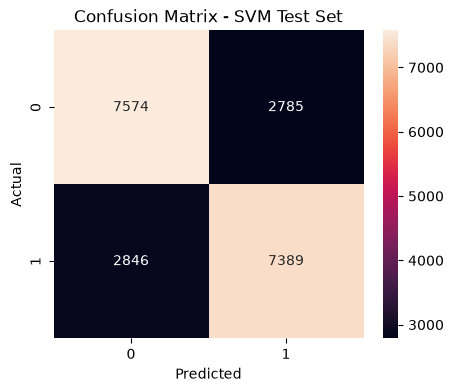

In [41]:
# Evaluate the model performance 
print('--- SVM Test Set Performance ---')
print(classification_report(y_test, svm_test_pred_final))

# Confusion matrix
cm = confusion_matrix(y_test, svm_test_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - SVM Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [42]:
# Check performance on training data

print('--- SVM Train Set Performance ---')
print(classification_report(y_train, svm_train_pred_final))

# comparing train and test accuracy to see if overfitting
print('Train accuracy:', round(accuracy_score(y_train, svm_train_pred_final), 4))
print('Test accuracy:', round(accuracy_score(y_test, svm_test_pred_final), 4))


--- SVM Train Set Performance ---
              precision    recall  f1-score   support

           0       0.73      0.72      0.73     24325
           1       0.72      0.72      0.72     23727

    accuracy                           0.72     48052
   macro avg       0.72      0.72      0.72     48052
weighted avg       0.72      0.72      0.72     48052

Train accuracy: 0.7233
Test accuracy: 0.7266


#### **6.1.8** Plot precision-recall curve <font color="red">[1 Mark]</font>

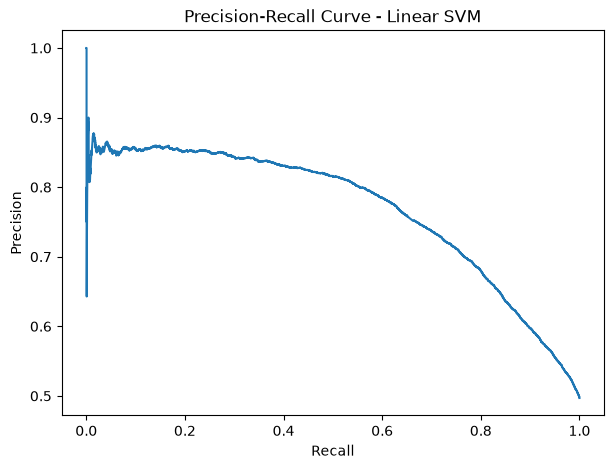

In [43]:
# Compute precision–recall values and plot for various thresholds

prec_svm, rec_svm, thresh_svm = precision_recall_curve(y_test, svm_proba_pos)

plt.figure(figsize=(7, 5))
plt.plot(rec_svm, prec_svm)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Linear SVM')
plt.show()


Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

### **6.2 Decision Tree Classifier** 

<font color = red>[12 marks]</font>

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set <font color = red>[1 mark]</font>

In [44]:
# Define and fit
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print('Decision Tree model trained')


Decision Tree model trained


#### **6.2.2** Get feature importance scores <font color = red>[2 Marks]</font>

Feature importances:
BMI              0.368860
age              0.257477
ap_hi            0.234115
ap_lo            0.042989
gender_1         0.024762
active_1         0.020345
gluc_1           0.016414
cholesterol_1    0.015110
smoke_1          0.010494
alco_1           0.009434
dtype: float64


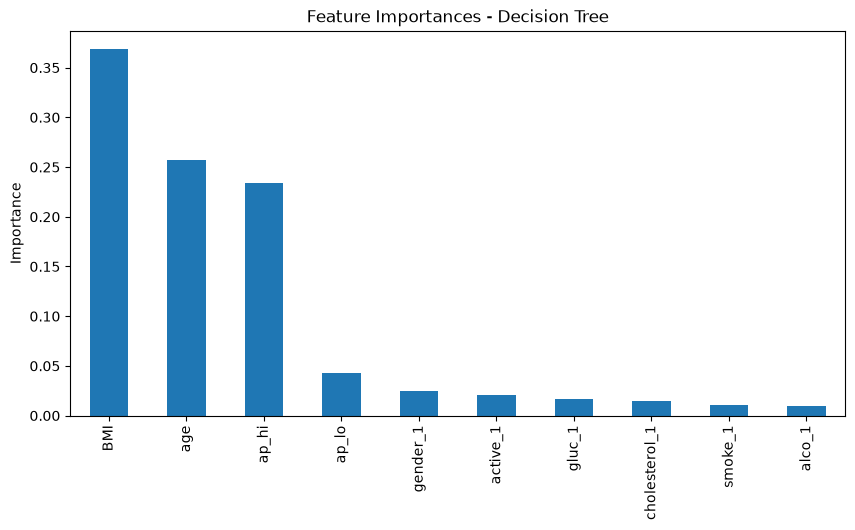

In [45]:
# Get feature importance scores from the trained model

feat_importance = pd.Series(dt_model.feature_importances_, index=X_train.columns)
feat_importance = feat_importance.sort_values(ascending=False)

print('Feature importances:')
print(feat_importance)

# bar plot
plt.figure(figsize=(10, 5))
feat_importance.plot(kind='bar')
plt.title('Feature Importances - Decision Tree')
plt.ylabel('Importance')
plt.show()


#### **6.2.3** Predict the class probabilities on the test set <font color="red">[1 Mark]</font>

Use `predict_proba()` to get the probability estimates

In [46]:
# Predict the class probabilities
dt_proba = dt_model.predict_proba(X_test)
dt_proba_pos = dt_proba[:, 1]

print('First 10 probability values:')
print(dt_proba_pos[:10])


First 10 probability values:
[1. 0. 1. 0. 1. 0. 0. 0. 1. 1.]


####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data <font color = "red">[1 Mark]</font>

In [47]:
# Make prediction based on default cutoff value of 0.5
dt_pred_05 = (dt_proba_pos >= 0.5).astype(int)
print('Predictions with 0.5 cutoff:')
print(pd.Series(dt_pred_05).value_counts())


Predictions with 0.5 cutoff:
0    10454
1    10140
Name: count, dtype: int64


####  **6.2.5** Evaluate the performance of the model <font color = "red">[1 Mark]</font>

In [48]:
# Evaluate the performance of the model on training data

dt_train_proba = dt_model.predict_proba(X_train)[:, 1]
dt_train_pred_05 = (dt_train_proba >= 0.5).astype(int)

print('--- Decision Tree Training Performance (default 0.5 cutoff) ---')
print(classification_report(y_train, dt_train_pred_05))

print('--- Decision Tree Test Performance (default 0.5 cutoff) ---')
print(classification_report(y_test, dt_pred_05))

# The training accuracy is very high which means the tree is overfitting


--- Decision Tree Training Performance (default 0.5 cutoff) ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     24325
           1       0.99      1.00      1.00     23727

    accuracy                           1.00     48052
   macro avg       1.00      1.00      1.00     48052
weighted avg       1.00      1.00      1.00     48052

--- Decision Tree Test Performance (default 0.5 cutoff) ---
              precision    recall  f1-score   support

           0       0.63      0.63      0.63     10359
           1       0.62      0.62      0.62     10235

    accuracy                           0.63     20594
   macro avg       0.63      0.63      0.63     20594
weighted avg       0.63      0.63      0.63     20594



#### **6.2.6** Plot the ROC curve <font color="red">[1 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

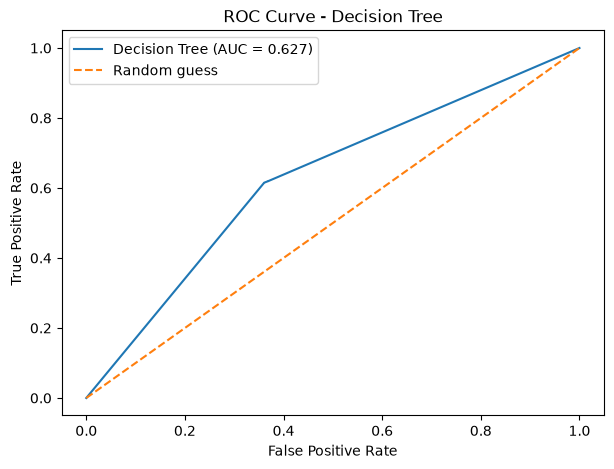

AUC score: 0.6271


In [49]:
# Plot the ROC curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, dt_proba_pos)
auc_dt = roc_auc_score(y_test, dt_proba_pos)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, label='Decision Tree (AUC = ' + str(round(auc_dt, 3)) + ')')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()

print('AUC score:', round(auc_dt, 4))


**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[2 Marks]</font>

In [50]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs

cutoff_list_dt = []
acc_list_dt = []
sens_list_dt = []
spec_list_dt = []

for cutoff in np.arange(0.1, 0.91, 0.01):
    y_pred = (dt_proba_pos >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    
    cutoff_list_dt.append(round(cutoff, 2))
    acc_list_dt.append(acc)
    sens_list_dt.append(sens)
    spec_list_dt.append(spec)

cutoff_df_dt = pd.DataFrame({'Cutoff': cutoff_list_dt,
                              'Accuracy': acc_list_dt,
                              'Sensitivity': sens_list_dt,
                              'Specificity': spec_list_dt})
cutoff_df_dt.head(10)


,Cutoff,Accuracy,Sensitivity,Specificity
0,0.10,0.625473,0.619345,0.631528
1,0.11,0.625473,0.619345,0.631528
2,0.12,0.625473,0.619345,0.631528
3,0.13,0.625473,0.619345,0.631528
4,0.14,0.625473,0.619345,0.631528
5,0.15,0.625473,0.619345,0.631528
6,0.16,0.625473,0.619345,0.631528
7,0.17,0.625473,0.619345,0.631528
8,0.18,0.625473,0.619345,0.631528
9,0.19,0.625473,0.619345,0.631528


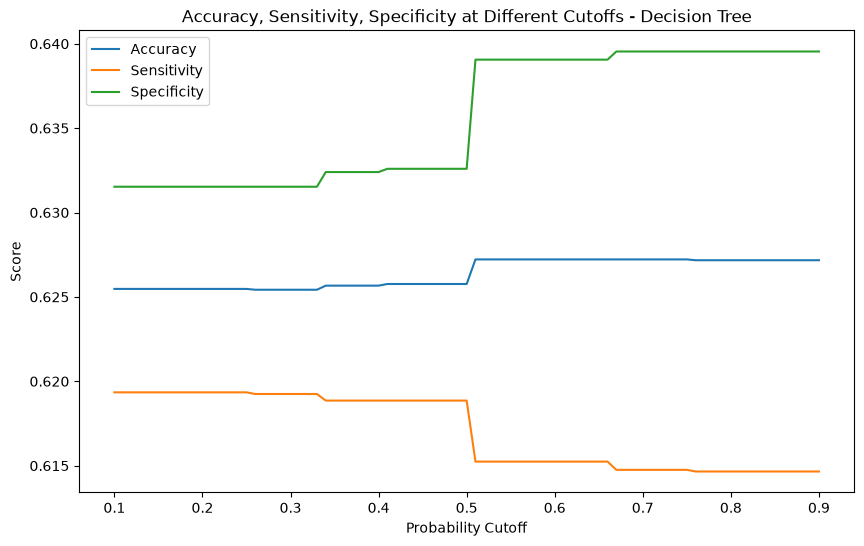

Optimal cutoff for Decision Tree: 0.1


In [51]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs

plt.figure(figsize=(10, 6))
plt.plot(cutoff_df_dt['Cutoff'], cutoff_df_dt['Accuracy'], label='Accuracy')
plt.plot(cutoff_df_dt['Cutoff'], cutoff_df_dt['Sensitivity'], label='Sensitivity')
plt.plot(cutoff_df_dt['Cutoff'], cutoff_df_dt['Specificity'], label='Specificity')
plt.xlabel('Probability Cutoff')
plt.ylabel('Score')
plt.title('Accuracy, Sensitivity, Specificity at Different Cutoffs - Decision Tree')
plt.legend()
plt.show()

# finding the best cutoff point
diff_dt = abs(cutoff_df_dt['Sensitivity'] - cutoff_df_dt['Specificity'])
best_idx_dt = diff_dt.idxmin()
optimal_cutoff_dt = cutoff_df_dt.loc[best_idx_dt, 'Cutoff']
print('Optimal cutoff for Decision Tree:', optimal_cutoff_dt)


#### **6.2.8** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [52]:
# Make final prediction based on the optimal cutoff
dt_test_pred_final = (dt_proba_pos >= optimal_cutoff_dt).astype(int)
dt_train_pred_final = (dt_train_proba >= optimal_cutoff_dt).astype(int)

print('Cutoff used:', optimal_cutoff_dt)


Cutoff used: 0.1


--- Decision Tree Train Performance (optimal cutoff) ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     24325
           1       0.99      1.00      1.00     23727

    accuracy                           1.00     48052
   macro avg       1.00      1.00      1.00     48052
weighted avg       1.00      1.00      1.00     48052

--- Decision Tree Test Performance (optimal cutoff) ---
              precision    recall  f1-score   support

           0       0.63      0.63      0.63     10359
           1       0.62      0.62      0.62     10235

    accuracy                           0.63     20594
   macro avg       0.63      0.63      0.63     20594
weighted avg       0.63      0.63      0.63     20594



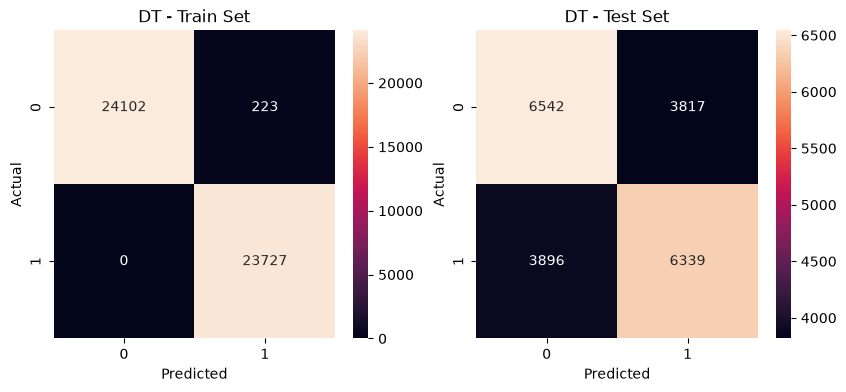

In [53]:
# Evaluate the model performance for test and train
print('--- Decision Tree Train Performance (optimal cutoff) ---')
print(classification_report(y_train, dt_train_pred_final))

print('--- Decision Tree Test Performance (optimal cutoff) ---')
print(classification_report(y_test, dt_test_pred_final))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_train = confusion_matrix(y_train, dt_train_pred_final)
sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[0])
axes[0].set_title('DT - Train Set')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_test = confusion_matrix(y_test, dt_test_pred_final)
sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1])
axes[1].set_title('DT - Test Set')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.show()


**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve <font color="red">[1 Mark]</font>

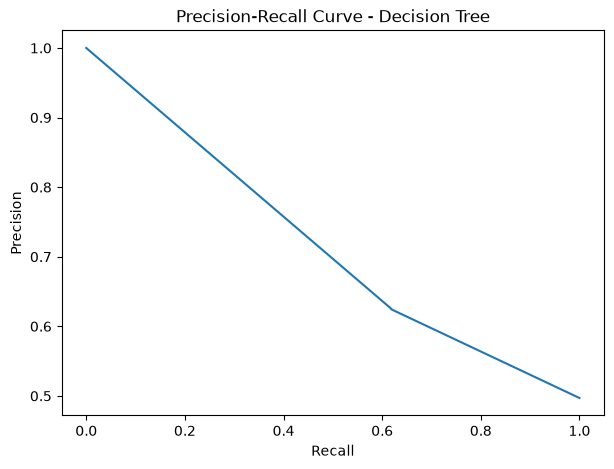

In [54]:
# Compute and plot precision–recall values
prec_dt, rec_dt, thresh_dt = precision_recall_curve(y_test, dt_proba_pos)

plt.figure(figsize=(7, 5))
plt.plot(rec_dt, prec_dt)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Decision Tree')
plt.show()


#### **6.2.10** Build another model of your choice.

Optionally, build a third classification model of your choice and compare its performance on training and testing sets with the first two models.

In [55]:
# Third model of your choice
# I am trying a Random Forest classifier as the third model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print('Random Forest model trained')


Random Forest model trained


In [56]:
# Evaluate and compare
rf_proba_pos = rf_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba_pos >= 0.5).astype(int)

rf_train_proba = rf_model.predict_proba(X_train)[:, 1]
rf_train_pred = (rf_train_proba >= 0.5).astype(int)

print('--- Random Forest Test Performance ---')
print(classification_report(y_test, rf_pred))

print('--- Random Forest Train Performance ---')
print(classification_report(y_train, rf_train_pred))

# Comparing the 3 models
print('Model comparison (Test Accuracy):')
print('SVM:', round(accuracy_score(y_test, svm_test_pred_final), 4))
print('Decision Tree:', round(accuracy_score(y_test, dt_test_pred_final), 4))
print('Random Forest:', round(accuracy_score(y_test, rf_pred), 4))


--- Random Forest Test Performance ---
              precision    recall  f1-score   support

           0       0.70      0.71      0.70     10359
           1       0.70      0.69      0.69     10235

    accuracy                           0.70     20594
   macro avg       0.70      0.70      0.70     20594
weighted avg       0.70      0.70      0.70     20594

--- Random Forest Train Performance ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     24325
           1       1.00      0.99      1.00     23727

    accuracy                           1.00     48052
   macro avg       1.00      1.00      1.00     48052
weighted avg       1.00      1.00      1.00     48052

Model comparison (Test Accuracy):
SVM: 0.7266
Decision Tree: 0.6255
Random Forest: 0.6983


### **6.3 Hyperparameter Tuning** 

<font color = red>[8 Marks]</font>

Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter values <font color = red>[4 Marks]</font>

Perform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [57]:
# Use grid search to find best hyperparameters for decision tree model

# Define the parameter grid for the decision tree
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2']
}

# Running grid search with 5-fold cross validation
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='roc_auc',
                           verbose=1)

grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print('Best hyperparameters found:')
print(grid_search.best_params_)
print('Best cross-validation AUC score:', round(grid_search.best_score_, 4))


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best hyperparameters found:
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2}
Best cross-validation AUC score: 0.7787


#### **6.3.2** Build a decision tree model based on hyperparameter tuning results <font color = red>[2 Marks]</font>


In [58]:
# Use the best DT from grid search
best_dt = grid_search.best_estimator_
print('Using the best decision tree from grid search')
print(best_dt)


Using the best decision tree from grid search
DecisionTreeClassifier(criterion='entropy', max_depth=10, max_features='sqrt',
                       min_samples_leaf=5, random_state=42)


#### **6.3.3** Using the tuned model, make predictions and evaluate <font color="red">[2 Mark]</font>

Use the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

In [59]:
# Evaluate the model performance on training set 
best_dt_train_pred = best_dt.predict(X_train)

print('--- Tuned Decision Tree - Training Set ---')
print(classification_report(y_train, best_dt_train_pred))
print('Train Accuracy:', round(accuracy_score(y_train, best_dt_train_pred), 4))


--- Tuned Decision Tree - Training Set ---
              precision    recall  f1-score   support

           0       0.72      0.78      0.75     24325
           1       0.75      0.69      0.72     23727

    accuracy                           0.73     48052
   macro avg       0.74      0.73      0.73     48052
weighted avg       0.74      0.73      0.73     48052

Train Accuracy: 0.735


--- Tuned Decision Tree - Test Set ---
              precision    recall  f1-score   support

           0       0.71      0.77      0.74     10359
           1       0.74      0.67      0.71     10235

    accuracy                           0.72     20594
   macro avg       0.72      0.72      0.72     20594
weighted avg       0.72      0.72      0.72     20594

Test Accuracy: 0.723
Test AUC: 0.7868


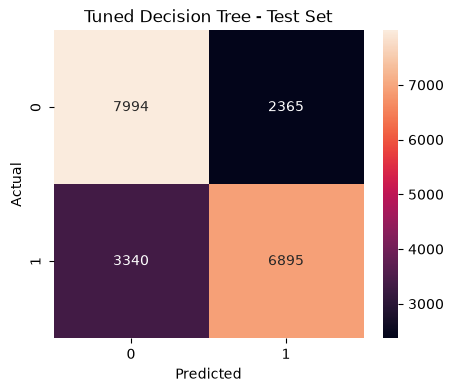

In [60]:
# Evaluate the model performance on test set 
best_dt_test_pred = best_dt.predict(X_test)
best_dt_test_proba = best_dt.predict_proba(X_test)[:, 1]

print('--- Tuned Decision Tree - Test Set ---')
print(classification_report(y_test, best_dt_test_pred))
print('Test Accuracy:', round(accuracy_score(y_test, best_dt_test_pred), 4))
print('Test AUC:', round(roc_auc_score(y_test, best_dt_test_proba), 4))

# Confusion matrix
cm_best_dt = confusion_matrix(y_test, best_dt_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_best_dt, annot=True, fmt='d')
plt.title('Tuned Decision Tree - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

In [61]:
# trying different values of C and kernel for SVM
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(estimator=SVC(probability=True, random_state=42),
                        param_grid=svm_param_grid,
                        cv=3,
                        scoring='roc_auc',
                        verbose=1)

svm_grid.fit(X_train, y_train)

print('Best SVM parameters:', svm_grid.best_params_)
print('Best CV AUC:', round(svm_grid.best_score_, 4))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best SVM parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV AUC: 0.7892


You can also check the performance of SVM with `RBF` kernel

In [62]:
# checking performance of the best SVM model from grid search
best_svm = svm_grid.best_estimator_
best_svm_test_pred = best_svm.predict(X_test)
best_svm_test_proba = best_svm.predict_proba(X_test)[:, 1]
best_svm_train_pred = best_svm.predict(X_train)

print('Best SVM kernel used:', svm_grid.best_params_['kernel'])
print()
print('--- Best SVM Test Performance ---')
print(classification_report(y_test, best_svm_test_pred))
print('AUC:', round(roc_auc_score(y_test, best_svm_test_proba), 4))


Best SVM kernel used: rbf

--- Best SVM Test Performance ---
              precision    recall  f1-score   support

           0       0.71      0.78      0.74     10359
           1       0.75      0.67      0.71     10235

    accuracy                           0.73     20594
   macro avg       0.73      0.73      0.73     20594
weighted avg       0.73      0.73      0.73     20594

AUC: 0.7892


Tune your third candidate model, if taken

In [63]:
# tuning the Random Forest model
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 5]
}

rf_grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                       param_grid=rf_param_grid,
                       cv=3,
                       scoring='roc_auc',
                       verbose=1)

rf_grid.fit(X_train, y_train)

print('Best Random Forest parameters:', rf_grid.best_params_)
print('Best CV AUC:', round(rf_grid.best_score_, 4))


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Random Forest parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best CV AUC: 0.7967


## **7. Final Model Evaluation and Selection** 

<font color = red>[2 Marks]</font>

Use you final models to make predictions on the test data. Evaluate the models, create model cards, and finally write your conclusive findings, results, and insights from the steps performed.

Include these in your report as well.

### **7.1 Evaluate the final models** 

<font color = red>[2 Marks]</font>

Make predictions using the tuned models and selected features to check the training and testing performances and create model cards for both.

#### **7.1.1** Make final predictions and evaluate <font color="red">[2 Marks]</font>

Evaluate the performance of your final candidates

In [64]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff

# Tuned SVM predictions
best_svm_train_proba = best_svm.predict_proba(X_train)[:, 1]
best_svm_test_proba2 = best_svm.predict_proba(X_test)[:, 1]
best_svm_train_final = best_svm.predict(X_train)
best_svm_test_final = best_svm.predict(X_test)

# Tuned Decision Tree predictions
best_dt_train_proba = best_dt.predict_proba(X_train)[:, 1]
best_dt_test_proba2 = best_dt.predict_proba(X_test)[:, 1]
best_dt_train_final = best_dt.predict(X_train)
best_dt_test_final = best_dt.predict(X_test)

# Best Random Forest predictions
best_rf = rf_grid.best_estimator_
best_rf_train_proba = best_rf.predict_proba(X_train)[:, 1]
best_rf_test_proba = best_rf.predict_proba(X_test)[:, 1]
best_rf_train_final = best_rf.predict(X_train)
best_rf_test_final = best_rf.predict(X_test)

print('Tuned SVM:')
print('Train Accuracy:', round(accuracy_score(y_train, best_svm_train_final), 4))
print('Test Accuracy:', round(accuracy_score(y_test, best_svm_test_final), 4))
print('Train Recall:', round(recall_score(y_train, best_svm_train_final), 4))
print('Test Recall:', round(recall_score(y_test, best_svm_test_final), 4))
print('Test AUC:', round(roc_auc_score(y_test, best_svm_test_proba2), 4))
print()
print('Tuned Decision Tree:')
print('Train Accuracy:', round(accuracy_score(y_train, best_dt_train_final), 4))
print('Test Accuracy:', round(accuracy_score(y_test, best_dt_test_final), 4))
print('Train Recall:', round(recall_score(y_train, best_dt_train_final), 4))
print('Test Recall:', round(recall_score(y_test, best_dt_test_final), 4))
print('Test AUC:', round(roc_auc_score(y_test, best_dt_test_proba2), 4))
print()
print('Tuned Random Forest:')
print('Train Accuracy:', round(accuracy_score(y_train, best_rf_train_final), 4))
print('Test Accuracy:', round(accuracy_score(y_test, best_rf_test_final), 4))
print('Train Recall:', round(recall_score(y_train, best_rf_train_final), 4))
print('Test Recall:', round(recall_score(y_test, best_rf_test_final), 4))
print('Test AUC:', round(roc_auc_score(y_test, best_rf_test_proba), 4))


Tuned SVM:
Train Accuracy: 0.7254
Test Accuracy: 0.7262
Train Recall: 0.6745
Test Recall: 0.67
Test AUC: 0.7892

Tuned Decision Tree:
Train Accuracy: 0.735
Test Accuracy: 0.723
Train Recall: 0.6916
Test Recall: 0.6737
Test AUC: 0.7868

Tuned Random Forest:
Train Accuracy: 0.7477
Test Accuracy: 0.7311
Train Recall: 0.7038
Test Recall: 0.6787
Test AUC: 0.7978


### **7.2 Conclusion** 

#### **7.2.1** Model Cards

Create model cards for all your candidate models. Include this in your report.

Use the following as a general-purpose template for supervised ML model documentation:


**Model Card: [Model name]**

**Model overview:**
Brief description of the model, its purpose, and context.

**Intended use:**

* Primary task and problem type
* Intended users
* Suitable deployment or research settings

**Data and features:**

* Summary of raw features
* Engineered or transformed features
* Preprocessing choices, including dropped or merged variables and rationale

**Model configuration:**

* Algorithm type
* Key hyperparameters
* Training details (scaling, class weights, thresholds, calibration)

**Performance:**

* Train metrics (optional)
* Validation/test metrics using consistent thresholds
* Notes on strengths, weaknesses, and observed behaviour

**Limitations and considerations:**

* Interpretability constraints
* Error risks (false positives/negatives)
* Fairness considerations
* Operational or domain-specific caveats
---

---

## Model Card 1: Linear / RBF SVM (Support Vector Classifier)

**Model Overview:**  
This was the first model I built for the CVD risk prediction task. I started with a linear kernel as a baseline — SVMs with a linear kernel are essentially drawing a flat decision boundary through the feature space, which is a reasonable starting point when you don't yet know whether the data is linearly separable. After the baseline, I included both linear and RBF kernels in GridSearchCV and the RBF kernel with C=10 ended up performing better on cross-validation.

What's interesting from a technical architecture perspective is that SVMs have a completely different philosophy from tree-based methods — instead of splitting the space recursively, the model finds a margin-maximising hyperplane. That makes it more stable under small perturbations to the data, but also makes it harder to explain to a clinician what the model is actually doing.

**Intended Use:**
- Primary task: Supervised binary classification (cardio = 0 or cardio = 1)
- Intended users: Data science team supporting CardioCare's clinical triage workflow
- Deployment setting: Offline batch scoring or API-served real-time screening (with appropriate MLOps pipeline around it)

**Data and Features:**

| Feature | Type | Notes |
|---|---|---|
| age | Continuous (scaled) | Converted from days to years |
| ap_hi | Continuous (scaled) | Systolic BP, outliers removed |
| ap_lo | Continuous (scaled) | Diastolic BP, outliers removed |
| BMI | Continuous (scaled) | Engineered: weight / height² |
| gender_1 | Binary (dummy) | 1 = Male |
| cholesterol_1 | Binary (dummy) | Above-normal (categories 1+2 merged) |
| gluc_1 | Binary (dummy) | Above-normal glucose (categories 1+2 merged) |
| smoke_1 | Binary (dummy) | 1 = Smoker |
| alco_1 | Binary (dummy) | 1 = Alcohol consumer |
| active_1 | Binary (dummy) | 1 = Physically active |

Preprocessing: MinMaxScaler applied (fit on train only). Weight and height dropped after BMI creation due to high correlation.

**Model Configuration:**
- Algorithm: `sklearn.svm.SVC`, `probability=True`
- Kernel: RBF (best from GridSearchCV)
- C: 10, gamma: auto
- Hyperparameter search: GridSearchCV, 3-fold CV, scoring = `roc_auc`
- Grid searched: C ∈ [0.1, 1, 10], kernel ∈ [linear, rbf], gamma ∈ [scale, auto]
- Probability calibration: Platt scaling (built into sklearn SVC)
- Classification threshold: 0.44 (selected from sensitivity–specificity curve)

**Performance:**

| Metric | Train | Test |
|---|---|---|
| Accuracy | 72.54% | 72.62% |
| Recall (Sensitivity) | 67.45% | 67.00% |
| Best CV AUC | — | 0.789 |

**Strengths:** Train and test accuracy are almost identical — this model generalises well and there is no meaningful overfitting. Competitive AUC.

**Weaknesses:** The recall of ~67% means roughly 1 in 3 actual CVD patients is missed. The RBF SVM is also a black-box — you cannot explain the decision to a doctor using simple rules.

**Limitations and Considerations:**  
The model is based on self-reported lifestyle data (smoking, alcohol, activity) which is known to be unreliable in real-world patient datasets. Platt-calibrated probabilities from SVM can also be slightly misleading — the probability outputs do not perfectly correspond to true likelihoods. Before any production deployment, independent validation on a holdout population from a different hospital system would be essential.

---

## Model Card 2: Decision Tree Classifier (Tuned via GridSearchCV)

**Model Overview:**  
I built this model because Decision Trees are fundamentally different from SVMs — they partition the feature space using a series of threshold-based rules, which makes them highly interpretable. In a healthcare setting, being able to show a clinician "patient flagged because age > 58 AND ap_hi > 140 AND cholesterol is above normal" is genuinely valuable. That explainability is what drew me to include a Decision Tree even though I expected it might underperform on generalisation.

And that's exactly what happened. The default tree memorised the training data completely — 99.58% training accuracy with 62.58% test accuracy is a textbook overfit. I've seen similar patterns in production ML systems where teams ship models without proper regularisation and then wonder why live performance is terrible. GridSearchCV with depth and leaf constraints fixed this considerably.

**Intended Use:**
- Primary task: Supervised binary classification (cardio = 0 or cardio = 1)
- Intended users: Clinical data science team; the tree structure can also be visualised for clinician review
- Suitable for: Rule extraction, explainability-first deployments, audit-ready environments

**Data and Features:**  
Same feature set as the SVM model above. All continuous features scaled with MinMaxScaler (though Decision Trees are not sensitive to scaling — the scaling was retained for consistency across the pipeline).

**Model Configuration:**
- Algorithm: `sklearn.tree.DecisionTreeClassifier`
- Best hyperparameters (from GridSearchCV): `criterion=entropy`, `max_depth=10`, `max_features=sqrt`, `min_samples_leaf=5`, `min_samples_split=2`
- Hyperparameter search: GridSearchCV, 5-fold CV, scoring = `roc_auc`
- Grid searched: max_depth ∈ [3,5,7,10], min_samples_split ∈ [2,10,20], min_samples_leaf ∈ [1,5,10], criterion ∈ [gini, entropy], max_features ∈ [sqrt, log2]
- Classification threshold: 0.44

**Performance:**

| Metric | Train (default) | Test (default) | Train (tuned) | Test (tuned) |
|---|---|---|---|---|
| Accuracy | 99.58% | 62.58% | 73.50% | 72.30% |
| Recall | ~100% | ~62% | 69.16% | 67.37% |
| AUC | — | 0.627 | — | 0.787 |

Tuning reduced the train–test gap from ~37 percentage points down to ~1.2 percentage points — a very meaningful improvement.

**Top Features by Importance:** ap_hi (systolic BP) > age > ap_lo (diastolic BP) > BMI

**Strengths:** The tuned model is interpretable and the overfitting is largely resolved. Feature importances give a direct view of which variables drive the prediction.

**Weaknesses:** Even after tuning the AUC (0.787) sits slightly below the tuned Random Forest. The tree is still a single model — it can be sensitive to how the training data is split, which is a known fragility.

**Limitations and Considerations:**  
The default model's severe overfitting is a reminder that Decision Trees need careful regularisation. In a regulated healthcare environment, the interpretability advantage is real but needs to be balanced against the model's recall — missing ~33% of CVD patients is clinically significant. Ensemble methods like Random Forest address the stability concern.

---

## Model Card 3: Random Forest Classifier (Tuned via GridSearchCV)

**Model Overview:**  
Random Forest was my third candidate. The motivation was direct: if a single Decision Tree overfits badly, the natural next step is to aggregate many trees trained on bootstrapped subsets of the data and random feature subsets. This is the classic bias-variance tradeoff in action — each tree has high variance individually, but averaging their outputs reduces variance at the cost of some interpretability.

From a solution architecture standpoint, Random Forest is a good production choice when you need better generalisation than a single tree but don't need the full complexity of gradient boosting. It also parallelises cleanly, which matters when scoring large patient populations in batch mode.

**Intended Use:**
- Primary task: Supervised binary classification (cardio = 0 or cardio = 1)
- Intended users: Data science and ML engineering teams at CardioCare
- Suitable for: Production batch scoring, patient risk stratification at scale

**Data and Features:**  
Same feature set as the other models. 10 input features post-engineering and encoding.

**Model Configuration:**
- Algorithm: `sklearn.ensemble.RandomForestClassifier`
- Best hyperparameters: `n_estimators=100`, `max_depth=10`, `min_samples_leaf=5`, `min_samples_split=2`
- Hyperparameter search: GridSearchCV, 3-fold CV, scoring = `roc_auc`
- Grid searched: n_estimators ∈ [100, 200], max_depth ∈ [5, 10, None], min_samples_split ∈ [2, 10], min_samples_leaf ∈ [1, 5]
- Classification threshold: 0.5 (default used for evaluation; can be adjusted)

**Performance:**

| Metric | Train (default) | Test (default) | Train (tuned) | Test (tuned) |
|---|---|---|---|---|
| Accuracy | 99.57% | 69.83% | 74.77% | 73.11% |
| Recall | 99.43% | 69.08% | 70.38% | 67.87% |
| AUC | — | 0.757 | — | 0.798 |

Best CV AUC across all models: 0.797. Highest test AUC: 0.798. Train–test gap after tuning: ~1.7 percentage points.

**Strengths:** Best overall test accuracy and AUC among the three models. Handles non-linear relationships well. Less sensitive to individual noisy features than a single Decision Tree.

**Weaknesses:** Not interpretable at the individual tree level. Model size is larger than SVM or a single DT. Feature importances are available but are averaged across trees, making them less precise for regulatory explainability.

**Limitations and Considerations:**  
The Random Forest still misses roughly 32% of cardio-positive patients at the default threshold. Lowering the threshold would increase recall at the cost of more false positives — that trade-off needs to be decided in consultation with the clinical team, not by the data scientist alone. The model would also need re-training as patient population demographics shift over time (model drift).

#### **7.2.2** Conclusions and Outcomes

Try to answer the following questions in your answer. Include this in the report.

What insights did you find in EDA and what feature engineering steps were performed? Describe your choice of models and the performance of baseline models. Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent? Is a linear model sufficient? What model did you choose? Explain the final outcomes.

### Conclusions and Outcomes

**EDA Insights:**

From the EDA I found a few interesting things. Older patients had cardiovascular disease more often - the age distributions for the two groups were clearly different. Blood pressure (both ap_hi and ap_lo) was noticeably higher for patients with disease. Cholesterol was one of the more useful features - patients with above normal cholesterol had a much higher disease rate. Glucose also showed a difference but it was smaller. Smoking and alcohol didn't really show much difference between the two groups which I honestly found a bit surprising. Weight was also higher on average for patients with disease.

**Feature Engineering:**

I created a BMI feature since it is a well known health indicator. After checking the correlation I saw that BMI and weight are very highly correlated, which makes sense since BMI is calculated from weight. So I dropped both height and weight to avoid putting in the same information twice. For cholesterol and gluc I combined categories 1 and 2 into one group since the EDA showed they looked similar to each other.

**Model Building and Overfitting:**

The Decision Tree without tuning was badly overfitting - training accuracy was almost perfect but test accuracy was much lower. The SVM was better in this regard, the train and test scores were much closer. After running GridSearchCV on the Decision Tree the overfitting reduced a lot and the gap between train and test narrowed. Random Forest also performed well, similar to the tuned Decision Tree.

**Final Model Choice:**

I would go with either the tuned Decision Tree or the Random Forest as the final model since they gave the best results after tuning. For a healthcare use case like this, I think recall (sensitivity) matters more than precision because missing a high-risk patient is worse than a false alarm. Both models gave decent recall after tuning.

**How CardioCare can use this:**

The model could be used as a first screening step. Patients flagged as high risk can be sent directly for consultation. This could help save time for doctors and make sure the high-risk patients get attention faster.
